<a href="https://colab.research.google.com/github/sanpazc/Python-programming-exercises/blob/master/nn_function_approximation_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Starter exercise: how does a neural network learn a function?

A neural network is given noisy measurements $\{x_i,y_i\}$ of an unknown function. We will keep the network fixed and change:

1. the function to be learned;
2. the number of training points.

Before running the main plot, predict where the network will fail.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(4)

## The three targets

They contain progressively shorter length scales: a straight line, a smooth oscillation, and a combination of slow and fast oscillations.

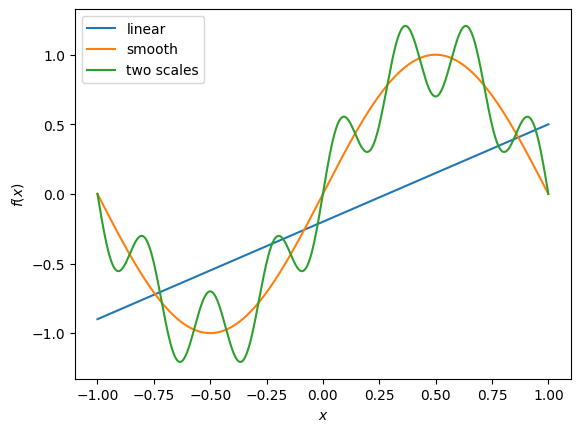

In [ ]:
functions = {
    'linear': lambda x: 0.7*x - 0.2,
    'smooth': lambda x: np.sin(np.pi*x),
    'two scales': lambda x: np.sin(np.pi*x) + 0.30*np.sin(7*np.pi*x),
}

x_plot = np.linspace(-1, 1, 600)
for name, f in functions.items():
    plt.plot(x_plot, f(x_plot), label=name)
plt.xlabel('$x$'); plt.ylabel('$f(x)$'); plt.legend(); plt.show()

## Fit the same network to every dataset

The dots are the training data, the black curve is the true function, and the red curve is the neural-network prediction. Look at the regions *between* data points, not only at the points themselves.

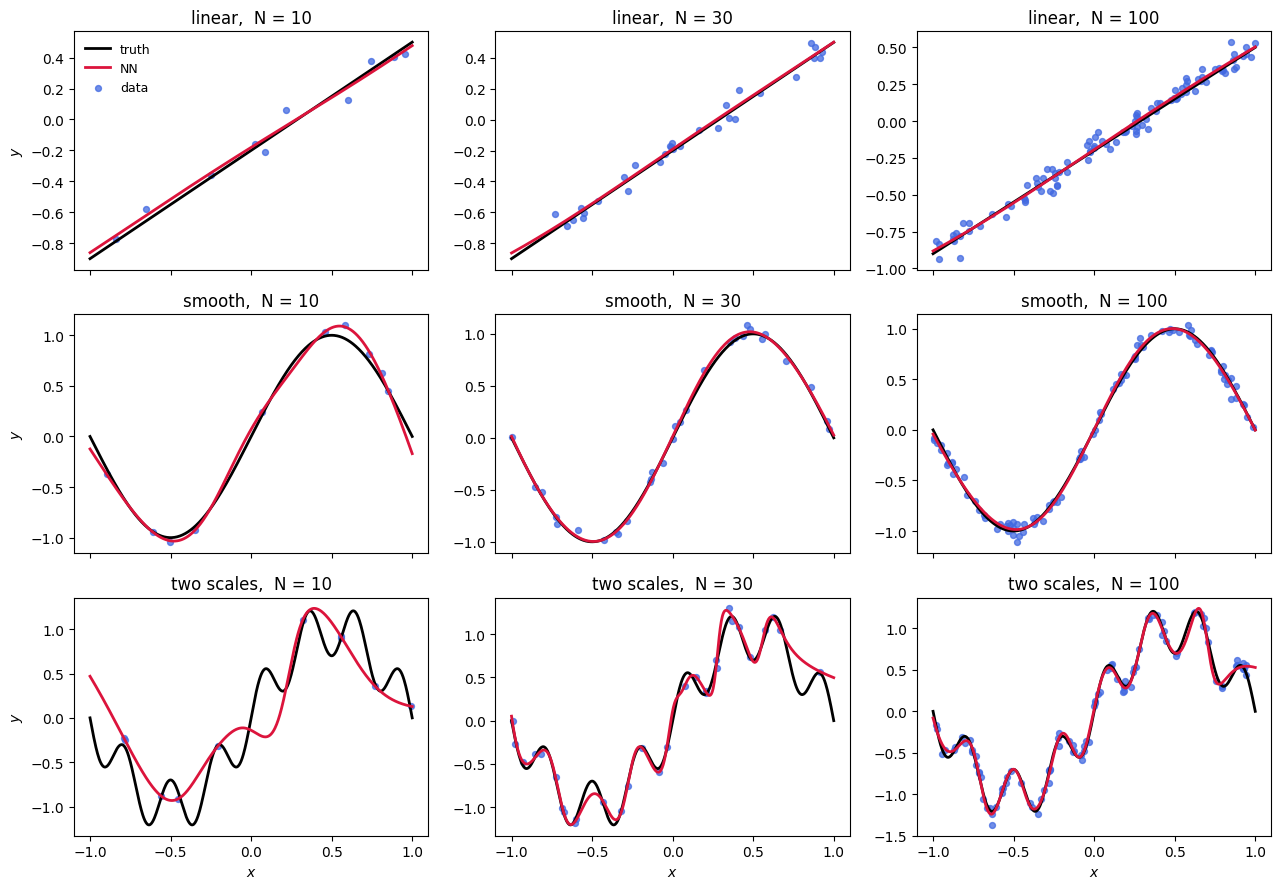

In [ ]:
sample_sizes = [10, 30, 100]
noise = 0.05
fig, axes = plt.subplots(len(functions), len(sample_sizes),
                         figsize=(13, 9), sharex=True)

for row, (name, f) in enumerate(functions.items()):
    for col, n_data in enumerate(sample_sizes):
        x_train = np.sort(rng.uniform(-1, 1, n_data))
        y_train = f(x_train) + rng.normal(0, noise, n_data)

        model = make_pipeline(
            StandardScaler(),
            MLPRegressor(hidden_layer_sizes=(32, 32), activation='tanh',
                         solver='lbfgs', max_iter=3000, random_state=1)
        )
        model.fit(x_train[:, None], y_train)
        prediction = model.predict(x_plot[:, None])

        ax = axes[row, col]
        ax.plot(x_plot, f(x_plot), color='black', lw=2, label='truth')
        ax.plot(x_plot, prediction, color='crimson', lw=2, label='NN')
        ax.scatter(x_train, y_train, s=18, color='royalblue', alpha=0.75,
                   label='data')
        ax.set_title(f'{name},  N = {n_data}')
        if col == 0: ax.set_ylabel('$y$')
        if row == len(functions)-1: ax.set_xlabel('$x$')

axes[0, 0].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Questions

1. Does the same number of points work equally well for all three functions? Why?
2. Can the network fit the observed points but still reconstruct the wrong function between them?
3. Is the relevant notion of complexity the formula's length, or the shortest scale on which the function changes?

### Two quick modifications

- Change the network from `(32, 32)` to `(8,)`, then to `(64, 64)`. Does a larger network compensate for missing data?
- Replace the uniformly sampled points by points only in `[-1, 0]`. What happens on `[0, 1]`? Is interpolation the same task as extrapolation?

## Take-home message

A sufficiently large neural network can represent very complicated functions, but representation is not the same as learning. The data must resolve the relevant structures, and a good fit to the training points does not guarantee reliable interpolation or extrapolation.